# Análisis de datos
### Nancy Armua | Brian Talavera 

## Preparación de ambiente 

In [34]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns
from utils import plot_histograma

### Fuente del dataset

Dataset recorridos Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/ff671909-6860-4398-8d0a-8f2389cb2780/download

Dataset ususarios Ecobicis 2023: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/edb5ed27-8506-43f0-88ce-3e5c0aa1a406/download


#### 1. Cargar datos desde un archivo CSV a un df de Pandas

In [35]:
path = "./dataset/"

df_recorridos = pd.read_csv(path + "trips_2023.csv")
df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


/tmp/ipykernel_190936/392836254.py:4: DtypeWarning: Columns (0: edad_usuario) have mixed types. Specify dtype option on import or set low_memory=False.
  df_usuarios = pd.read_csv(path + "usuarios_ecobici_2023.csv")


** A revisar: para el dataset de usuarios, edar_usuario aparentemente contiene datos mixtos.

## Exploración y comprensión de los datos
### Primeras filas de cada dataset


In [36]:
# Mostrar las primeras 5 filas de cada dataset
df_recorridos.head(5)


,Unnamed: 0,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,1,17910696BAEcobici,"1,848",2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,2,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,3,17255670BAEcobici,"1,103",2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,4,17996972BAEcobici,"1,165",2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,5,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [37]:
df_usuarios.head(5)

,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1083476,MALE,20,2023-12-31,19:24:57,Yes
1,1083080,FEMALE,18,2023-12-31,00:05:03,Yes
2,1083163,OTHER,27,2023-12-31,10:16:12,No
3,1083435,MALE,24,2023-12-31,17:42:11,Yes
4,1083376,OTHER,32,2023-12-31,16:16:15,No


#### Descripción del dataset de usuarios


| Variable | Descripción | Tipo |
| --- | --- | --- |
| `ID_usuario` | Identificador único del usuario | Categórica nominal |
| `genero_usuario` | Género autopercibido declarado por el usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |
| `edad_usuario` | Edad del usuario en años | Cuantitativa discreta |
| `fecha_alta` | Fecha de alta del usuario en el sistema | Categórica / Cuantitativa |
| `hora_alta` | Hora de alta del usuario en el sistema | Cuantitativa continua |
| `Customer.Has.Dni..Yes...No.` | Indica si el usuario cuenta con DNI registrado (`Yes`/`No`) | Categórica nominal |


#### Descripción del dataset de recorridos

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `Id_recorrido` | Identificador único del recorrido | Categórica nominal |
| `duracion_recorrido` | Duración del recorrido (en segundos) | Cuantitativa continua |
| `fecha_origen_recorrido` | Fecha y hora de inicio del recorrido | Categórica / Cuantitativa |
| `id_estacion_origen` | Identificador de la estación de origen | Categórica nominal |
| `nombre_estacion_origen` | Nombre de la estación de origen | Categórica nominal |
| `direccion_estacion_origen` | Dirección de la estación de origen | Categórica nominal |
| `long_estacion_origen` | Longitud geográfica de la estación de origen | Cuantitativa continua |
| `lat_estacion_origen` | Latitud geográfica de la estación de origen | Cuantitativa continua |
| `fecha_destino_recorrido` | Fecha y hora de finalización del recorrido | Categórica / Cuantitativa |
| `id_estacion_destino` | Identificador de la estación de destino | Categórica nominal |
| `nombre_estacion_destino` | Nombre de la estación de destino | Categórica nominal |
| `direccion_estacion_destino` | Dirección de la estación de destino | Categórica nominal |
| `long_estacion_destino` | Longitud geográfica de la estación de destino | Cuantitativa continua |
| `lat_estacion_destino` | Latitud geográfica de la estación de destino | Cuantitativa continua |
| `id_usuario` | Identificador del usuario que realizó el recorrido | Categórica nominal |
| `modelo_bicicleta` | Modelo de la bicicleta utilizada (`ICONIC`, `FIT`) | Categórica nominal |
| `género` | Género autopercibido del usuario (`MALE`, `FEMALE`, `OTHER`) | Categórica nominal |


### Definición del problema de ML que se quiere resolver

Predecir la duración de un recorrido, primero definir categorias de duración de recorrido, luego predecir la categoría a la que pertenece un recorrido dado.

### Unificación de datasets

**Problema:** `df_usuarios` solo contiene a los usuarios registrados durante 2023 (136.066 usuarios, todos con `fecha_alta` en 2023), mientras que `df_recorridos` contiene los viajes de *todos* los usuarios, incluidos los que se registraron en años anteriores. Por eso solo una parte de los recorridos se puede relacionar con un usuario del otro dataset.

**Decisión:** en lugar de unir los datasets y descartar filas, creamos la columna booleana `usuario_2023` en `df_recorridos`:
- `True`: el usuario fue registrado en 2023 (su id está en `df_usuarios`).
- `False`: el usuario no está en `df_usuarios`, por lo que fue registrado antes de 2023.

**Resultado:** 637.480 recorridos (24,31%) son de usuarios nuevos y 1.984.851 (75,69%) de usuarios anteriores. Un inner join habría eliminado ese 75,69% y la muestra quedaría sesgada hacia los usuarios nuevos; con la columna se conservan los 2.622.331 recorridos y se pueden comparar ambos grupos.

**Cómo se calcula:**
1. El `id_usuario` de recorridos tiene el formato `"861866BAEcobici"` y el `ID_usuario` de usuarios es numérico (`1083080`). Se presume que el primero es el segundo más el sufijo `BAEcobici`.
2. Se extrae la parte numérica con la expresión regular `(\d+)` y se la convierte a entero. Se hace en una variable aparte (`id_numerico`) para no modificar `id_usuario`.
3. Se marca `True` cuando ese número está en `ID_usuario` (`isin`).

**Limitación:** `usuario_2023` indica *si* el usuario es de 2023, pero no trae sus datos de `df_usuarios`. Evaluamos qué se perdería al no unir los datasets:
- `genero_usuario`: **no se pierde nada**, porque `df_recorridos` ya contiene `genero`, por lo que unirlo sería redundante.
- `edad_usuario`: es el **único dato relevante que perdemos**, y solo estaría disponible para los usuarios nuevos (24,31% de los recorridos).
- `fecha_alta`, `hora_alta` y `dni`: aportan poco al análisis de los recorridos.

Si más adelante se necesita la edad, se puede hacer un *left join* con `df_usuarios`, que completará ese campo solo para los usuarios nuevos; para el resto quedará vacío.


In [38]:
id_numerico = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos["usuario_2023"] = id_numerico.isin(df_usuarios["ID_usuario"].astype(int))

print(df_recorridos["usuario_2023"].value_counts())
print(f"Recorridos de usuarios nuevos: {df_recorridos['usuario_2023'].mean() * 100:.2f}%")

usuario_2023
False    1984851
True      637480
Name: count, dtype: int64
Recorridos de usuarios nuevos: 24.31%


### 2. Diagnóstico inicial: dimensiones, tipos de datos, duplicados y valores faltantes


In [39]:
for nombre, df in [("recorridos", df_recorridos)]:
    print(f"\n===== {nombre.upper()} =====")
    print("Dimensiones (filas, columnas):", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nDuplicados exactos:", df.duplicated().sum())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())



===== RECORRIDOS =====
Dimensiones (filas, columnas): (2622331, 19)

Tipos de datos:
Unnamed: 0                      int64
Id_recorrido                      str
duracion_recorrido                str
fecha_origen_recorrido            str
id_estacion_origen                str
nombre_estacion_origen            str
direccion_estacion_origen         str
long_estacion_origen          float64
lat_estacion_origen           float64
fecha_destino_recorrido           str
id_estacion_destino               str
nombre_estacion_destino           str
direccion_estacion_destino        str
long_estacion_destino         float64
lat_estacion_destino          float64
id_usuario                        str
modelo_bicicleta                  str
género                            str
usuario_2023                     bool
dtype: object

Duplicados exactos: 0

Valores nulos por columna:
Unnamed: 0                        0
Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorr

#### Número de observaciones y de variables (consigna, punto 2)


In [40]:
for nombre, df in [("usuarios", df_usuarios), ("recorridos", df_recorridos)]:
    print(f"{nombre}: {df.shape[0]:,} observaciones y {df.shape[1]} variables")


usuarios: 136,066 observaciones y 6 variables
recorridos: 2,622,331 observaciones y 19 variables


### Inspeccionar y corregir tipos de datos

Como se vio en clase, Pandas no siempre asigna el dtype correcto al importar un CSV: hay que
revisar cada variable y asignar el tipo que le corresponde (numérica, categórica u fecha).


In [41]:
df_recorridos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 19 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Unnamed: 0                  int64  
 1   Id_recorrido                str    
 2   duracion_recorrido          str    
 3   fecha_origen_recorrido      str    
 4   id_estacion_origen          str    
 5   nombre_estacion_origen      str    
 6   direccion_estacion_origen   str    
 7   long_estacion_origen        float64
 8   lat_estacion_origen         float64
 9   fecha_destino_recorrido     str    
 10  id_estacion_destino         str    
 11  nombre_estacion_destino     str    
 12  direccion_estacion_destino  str    
 13  long_estacion_destino       float64
 14  lat_estacion_destino        float64
 15  id_usuario                  str    
 16  modelo_bicicleta            str    
 17  género                      str    
 18  usuario_2023                bool   
dtypes: bool(1), float64(4), int64(1)

In [42]:
# Creamos funcion para asignar tipos de datos a las columnas
def asignar_tipos(df, tipos):
    """Convierte cada columna de `tipos` al dtype indicado."""
    for columna, tipo in tipos.items():
        if tipo == "datetime64[ns]":
            df[columna] = pd.to_datetime(df[columna])
        elif tipo in ("float64", "Int64"):
            # errors="coerce": los valores no numéricos quedan como NaN
            df[columna] = pd.to_numeric(df[columna], errors="coerce").astype(tipo)
        else:
            df[columna] = df[columna].astype(tipo)
    return df

In [43]:
# Asignacion de tipos de datos segun la tabla de variables

genero_category = CategoricalDtype(categories=["MALE", "FEMALE", "OTHER"])
modelos_bicicletas_category = CategoricalDtype(categories=["ICONIC", "FIT"])
dni_category = CategoricalDtype(categories=["Yes", "No"])

# remover acento del nombre de la columna para facilitar el tipado
df_recorridos = df_recorridos.rename(columns={"género": "genero"})

# duracion_recorrido viene con separador de miles ("1,848"): se quita antes de convertir
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"].astype(str).str.replace(",", "", regex=False)

TIPOS_RECORRIDOS = {
    "Id_recorrido": "category",
    "duracion_recorrido": "float64",
    "fecha_origen_recorrido": "datetime64[ns]",
    "id_estacion_origen": "category",
    "nombre_estacion_origen": "category",
    "direccion_estacion_origen": "category",
    "long_estacion_origen": "float64",
    "lat_estacion_origen": "float64",
    "fecha_destino_recorrido": "datetime64[ns]",
    "id_estacion_destino": "category",
    "nombre_estacion_destino": "category",
    "direccion_estacion_destino": "category",
    "long_estacion_destino": "float64",
    "lat_estacion_destino": "float64",
    "id_usuario": "category",
    "modelo_bicicleta": modelos_bicicletas_category,
    "genero": genero_category,
}

df_recorridos = asignar_tipos(df_recorridos, TIPOS_RECORRIDOS)

In [44]:
# la primera columna carece devalor por ende la eliminanos
df_recorridos.drop(df_recorridos.columns[0], axis=1, inplace=True)

In [45]:
# revisamos los nulos nuevamente para ver como qudamos luego de la conversion de tipos datos
df_recorridos.isnull().sum()

Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
genero                        11966
usuario_2023                      0
dtype: int64

Vemos que tenemos nulos en algunas columnas referidas a la estación
como son una porcion ínfima de nuestro dataset decidimos eliminarlos
en cuento a la variable genero, se analizara mas adelante

In [46]:
# eliminamos los pocos nulos de las meniconadas columnas
df_recorridos.dropna(
    subset=[
        "id_estacion_destino",
        "nombre_estacion_destino",
        "direccion_estacion_destino",
        "long_estacion_destino",
        "lat_estacion_destino",
    ],
    inplace=True
)

In [47]:
# realizamos el mismo proceso con el dataset de usuarios
df_usuarios.dtypes

ID_usuario                      int64
genero_usuario                    str
edad_usuario                   object
fecha_alta                        str
hora_alta                         str
Customer.Has.Dni..Yes...No.       str
dtype: object

In [48]:
# --- df_usuarios: tipos segun la tabla de variables ---
# renombrar la columna de DNI para facilitar el tipado
df_usuarios = df_usuarios.rename(columns={"Customer.Has.Dni..Yes...No.": "dni"})

TIPOS_USUARIOS = {
    "ID_usuario": "category",
    "genero_usuario": genero_category,
    "edad_usuario": "Int64",   # llega como texto; los no numéricos quedan como NaN
    "fecha_alta": "datetime64[ns]",
    "dni": dni_category,
}

df_usuarios = asignar_tipos(df_usuarios, TIPOS_USUARIOS)

# hora_alta (HH:MM:SS) -> timedelta desde la medianoche
df_usuarios["hora_alta"] = pd.to_timedelta(df_usuarios["hora_alta"])

df_usuarios.dtypes

ID_usuario               category
genero_usuario           category
edad_usuario                Int64
fecha_alta         datetime64[us]
hora_alta         timedelta64[us]
dni                      category
dtype: object

In [49]:
# revisamos los nulos
df_usuarios.isnull().sum()

ID_usuario        0
genero_usuario    0
edad_usuario      1
fecha_alta        0
hora_alta         0
dni               0
dtype: int64

Para el dataset de usuarios no hay nulos significativos

### Unir datasets

En esta seccion analizamos como podemos unir los dos datasets para trabajar los datos en conjunto

In [50]:
# Primero comparemos columnas de ambos datasets lado a lado para ver como podemos unirlos
pd.DataFrame({
    "df_usuarios": pd.Series(df_usuarios.columns),
    "df_recorridos": pd.Series(df_recorridos.columns),
}).fillna("")

,df_usuarios,df_recorridos
0,ID_usuario,Id_recorrido
1,genero_usuario,duracion_recorrido
2,edad_usuario,fecha_origen_recorrido
3,fecha_alta,id_estacion_origen
4,hora_alta,nombre_estacion_origen
5,dni,direccion_estacion_origen
6,,long_estacion_origen
7,,lat_estacion_origen
8,,fecha_destino_recorrido
9,,id_estacion_destino


In [51]:
# mostrar porcentaje de usuarios presentes en el dataset de recorridos
# df_usuarios contine los usuarios registrdos en 2023 unicamente
# df_recorridos contiene los recorridos realizados en 2023, que pueden incluir usuarios registrados en años anteriores
usuarios_recorridos = df_recorridos["id_usuario"].unique()
usuarios_registrados = df_usuarios["ID_usuario"].unique()
print(f"Usuarios registrados en 2023: {len(usuarios_registrados):,}")
print(f"Usuarios que realizaron recorridos en 2023: {len(usuarios_recorridos):,}")



Usuarios registrados en 2023: 136,066
Usuarios que realizaron recorridos en 2023: 212,068


#### Decisión de unificación: columna `usuario_2023`

**Punto de partida**
- `df_usuarios` contiene únicamente a los usuarios **registrados durante 2023** (todas las `fecha_alta` son de 2023).
- `df_recorridos` contiene los viajes de **todos** los usuarios, incluidos los registrados en años anteriores.
- Solo el **24,31%** de los recorridos (637.480 de 2.622.331) pertenece a un usuario presente en `df_usuarios`. El 75,69% restante corresponde a usuarios anteriores a 2023, de los que no tenemos edad, género, DNI ni fecha de alta.

**Por qué no usamos un inner join**
Un inner join descartaría ese 75,69% de recorridos. Perderíamos la gran mayoría de los viajes y la muestra quedaría sesgada hacia usuarios nuevos, por lo que las conclusiones sobre duración, estaciones u horarios no representarían al uso real del sistema.

**Qué hacemos en su lugar**
Se agrega la columna booleana `usuario_2023` a `df_recorridos`:
- `True`: el usuario fue registrado en 2023, es decir, su id está en `df_usuarios`.
- `False`: todos los demás (usuarios registrados antes de 2023).

Ventajas de esta decisión:
1. **No se pierde ninguna fila**: los 2.622.331 recorridos se mantienen.
2. **Distingue dos grupos comparables** (nuevos vs. anteriores), útil para analizar si se comportan distinto.
3. **No inventa datos**: no se completan edad, género ni DNI de los usuarios que no están en `df_usuarios`.
4. Mantiene la posibilidad de hacer más adelante un *left join* con `df_usuarios` para los usuarios nuevos y trabajar con su perfil.

**Detalle técnico**
El `id_usuario` de recorridos tiene el formato `"861866BAEcobici"`, mientras que `ID_usuario` en usuarios es numérico (`1083080`). Para compararlos se extrae la parte numérica con una expresión regular. El resultado se calcula aparte, sin modificar `id_usuario`, que se transforma recién más adelante en el análisis de la relación entre ambos datasets.

In [52]:
# usuario_2023: True si el usuario fue registrado en 2023 (está en df_usuarios), False para el resto
# el id de recorridos trae el sufijo "BAEcobici", se extrae la parte numérica para compararlo
id_numerico = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos["usuario_2023"] = id_numerico.isin(df_usuarios["ID_usuario"].astype(int))

print(df_recorridos["usuario_2023"].value_counts())
print(f"Recorridos de usuarios nuevos: {df_recorridos['usuario_2023'].mean() * 100:.2f}%")

usuario_2023
False    1984850
True      637479
Name: count, dtype: int64
Recorridos de usuarios nuevos: 24.31%


In [53]:
df_recorridos.dtypes

Id_recorrido                        category
duracion_recorrido                   float64
fecha_origen_recorrido        datetime64[us]
id_estacion_origen                  category
nombre_estacion_origen              category
direccion_estacion_origen           category
long_estacion_origen                 float64
lat_estacion_origen                  float64
fecha_destino_recorrido       datetime64[us]
id_estacion_destino                 category
nombre_estacion_destino             category
direccion_estacion_destino          category
long_estacion_destino                float64
lat_estacion_destino                 float64
id_usuario                          category
modelo_bicicleta                    category
genero                              category
usuario_2023                            bool
dtype: object

### 4. Estadística descriptiva general


In [54]:

df_recorridos.describe()

,duracion_recorrido,fecha_origen_recorrido,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,long_estacion_destino,lat_estacion_destino
count,2.622329e+06,2622329,2.622329e+06,2.622329e+06,2622329,2.622329e+06,2.622329e+06
mean,1.380614e+03,2023-07-01 12:17:00.476827,-5.841950e+01,-3.459812e+01,2023-07-01 12:40:01.090498,-5.841985e+01,-3.459819e+01
min,6.100000e+01,2023-01-01 00:06:08,-5.852602e+01,-3.468176e+01,2023-01-01 00:12:22,-5.852602e+01,-3.468176e+01
25%,5.720000e+02,2023-03-23 19:14:44,-5.844507e+01,-3.461495e+01,2023-03-23 19:36:32,-5.844600e+01,-3.461533e+01
50%,9.320000e+02,2023-06-30 16:16:42,-5.841601e+01,-3.460014e+01,2023-06-30 16:36:21,-5.841601e+01,-3.459978e+01
75%,1.513000e+03,2023-10-08 14:28:42,-5.838997e+01,-3.458373e+01,2023-10-08 15:07:05,-5.839009e+01,-3.458332e+01
max,6.208259e+06,2023-12-31 23:59:23,-5.835547e+01,-3.453669e+01,2024-01-02 14:35:15,-5.835547e+01,-3.453669e+01
std,1.242788e+04,NaN,3.730777e-02,2.285399e-02,NaN,3.757239e-02,2.324947e-02


La varible numérica que mas nos importa es 'duracion_recorrido'.
La misma se encuentra en segundos, lo cual se puede comprobar haciendo `decha_destino_recorrido` - `fecha_origen_recorrido`

In [55]:
# verificamos que lo enunciado anteriormente sea correcto
subset = df_recorridos[["duracion_recorrido", "fecha_origen_recorrido", "fecha_destino_recorrido"]].sample(10, random_state=42).copy()

subset["duracion_calculada"] = (subset["fecha_destino_recorrido"] - subset["fecha_origen_recorrido"]).dt.total_seconds()
subset["coincide"] = subset["duracion_recorrido"] == subset["duracion_calculada"]

print("Coinciden todas las filas:", subset["coincide"].all())
subset

Coinciden todas las filas: True


,duracion_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_calculada,coincide
2591607,683.0,2023-12-04 20:06:52,2023-12-04 20:18:15,683.0,True
2234180,1427.0,2023-09-19 18:29:16,2023-09-19 18:53:03,1427.0,True
221768,521.0,2023-06-21 09:43:07,2023-06-21 09:51:48,521.0,True
8977,589.0,2023-03-07 16:40:58,2023-03-07 16:50:47,589.0,True
675301,2229.0,2023-02-21 13:59:10,2023-02-21 14:36:19,2229.0,True
1339137,850.0,2023-08-16 13:00:29,2023-08-16 13:14:39,850.0,True
506890,362.0,2023-03-31 15:59:56,2023-03-31 16:05:58,362.0,True
1451428,914.0,2023-08-25 08:36:20,2023-08-25 08:51:34,914.0,True
1938091,495.0,2023-11-03 12:00:50,2023-11-03 12:09:05,495.0,True
1995526,2373.0,2023-11-09 18:47:58,2023-11-09 19:27:31,2373.0,True


In [56]:
# la varible de duracion en segundos resulta dificil de interpretar, por ende transformamos a minutos
# tambien renombramos la columna como duracion_recorrido_min
df_recorridos["duracion_recorrido"] = df_recorridos["duracion_recorrido"] / 60
df_recorridos = df_recorridos.rename(columns={"duracion_recorrido": "duracion_recorrido_min"})


In [57]:
print("Duracion media: ", df_recorridos['duracion_recorrido_min'].mean().round(1))
print("Duracion maxima: ", df_recorridos['duracion_recorrido_min'].max().round(1))
print("Duracion minima: ", df_recorridos['duracion_recorrido_min'].min().round(1))
print("Desviacion estandar: ", df_recorridos['duracion_recorrido_min'].std().round(1))

Duracion media:  23.0
Duracion maxima:  103471.0
Duracion minima:  1.0
Desviacion estandar:  207.1


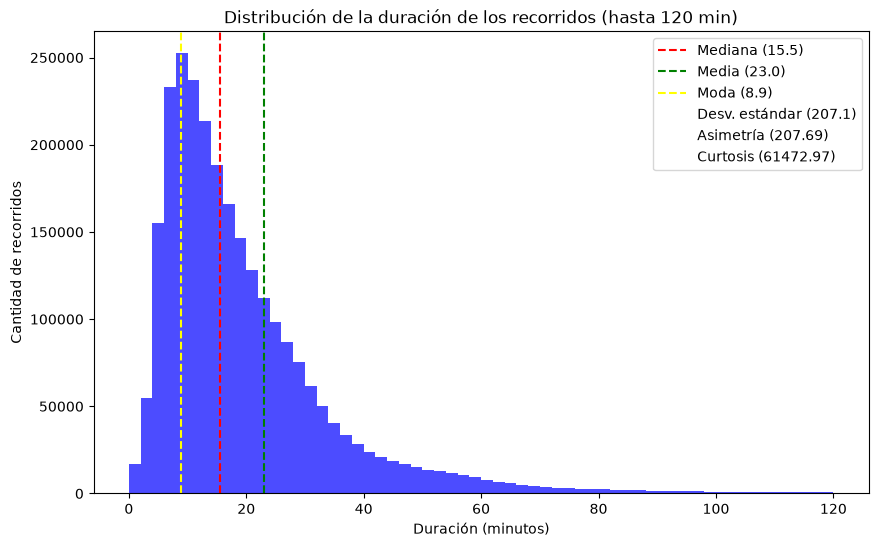

In [58]:
fig, plot = plt.subplots(figsize=(10, 6))

moda = df_recorridos['duracion_recorrido_min'].mode()[0]
mediana = df_recorridos['duracion_recorrido_min'].median()
media = df_recorridos['duracion_recorrido_min'].mean()
skewness = df_recorridos['duracion_recorrido_min'].skew()
curtosis = df_recorridos['duracion_recorrido_min'].kurtosis()

desviacion_estandar = df_recorridos['duracion_recorrido_min'].std()

# se grafica hasta 120 min, esto de sebe a que hay valures muy grandes de recorrido (outliers)
# que hacen que el grafico que inilegible cuando se incluyen
limite_min = 120
plot.hist(df_recorridos['duracion_recorrido_min'], bins=60, range=(0, limite_min), color='blue', alpha=0.7)

plot.axvline(mediana, color='red', linestyle='--', label='Mediana ({:.1f})'.format(mediana))
plot.axvline(df_recorridos['duracion_recorrido_min'].mean(), color='green', linestyle='--', label='Media ({:.1f})'.format(media))
plot.axvline(df_recorridos['duracion_recorrido_min'].mode()[0], color='yellow', linestyle='--', label='Moda ({:.1f})'.format(moda))
plot.plot([], [], ' ', label='Desv. estándar ({:.1f})'.format(desviacion_estandar))
plot.plot([], [], ' ', label='Asimetría ({:.2f})'.format(skewness))
plot.plot([], [], ' ', label='Curtosis ({:.2f})'.format(curtosis))

plot.set_title('Distribución de la duración de los recorridos (hasta 120 min)')
plot.set_xlabel('Duración (minutos)')
plot.set_ylabel('Cantidad de recorridos')
plot.legend()

plt.show()

Vemos que la distribucion de recorridos es prfundamente asimétrica y aparentemente contine muchos outliers en la zona derecha.

In [59]:
# outliers (criterio del rango intercuartílico)
duracion = df_recorridos['duracion_recorrido_min']
Q1 = duracion.quantile(0.25)
Q3 = duracion.quantile(0.75)
IQR = Q3 - Q1

# la duración no puede ser negativa, por lo que el límite inferior se acota en 0
limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

limite_inferior_count = (duracion < limite_inferior).sum()
limite_superior_count = (duracion > limite_superior).sum()

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Cantidad de recorridos por debajo del límite inferior ({limite_inferior:.2f} min): {limite_inferior_count:,}")
print(f"Cantidad de recorridos por encima del límite superior ({limite_superior:.2f} min): {limite_superior_count:,}")
print(f"Porcentaje de recorridos por debajo del límite inferior: {limite_inferior_count / len(duracion) * 100:.2f}%")
print(f"Porcentaje de recorridos por encima del límite superior: {limite_superior_count / len(duracion) * 100:.2f}%")



Q1: 9.53, Q3: 25.22, IQR: 15.68
Cantidad de recorridos por debajo del límite inferior (0.00 min): 0
Cantidad de recorridos por encima del límite superior (48.74 min): 156,752
Porcentaje de recorridos por debajo del límite inferior: 0.00%
Porcentaje de recorridos por encima del límite superior: 5.98%


In [60]:
print("cantidad de recorridos por encima de 240 minutos: ", (duracion > 120).sum())

cantidad de recorridos por encima de 240 minutos:  19565


In [61]:
print("Estadística descriptiva - variables categóricas (df_recorridos):\n")
# count = cant. de datos no nulos | unique = cant. de categorías | top = categoría más frecuente | freq = su frecuencia
df_recorridos.describe(include="category")


Estadística descriptiva - variables categóricas (df_recorridos):



,Id_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,id_usuario,modelo_bicicleta,genero
count,2622329,2622329,2622329,2622329,2622329,2622329,2622329,2622329,2622329,2610363
unique,2622329,364,365,370,365,366,371,212068,2,3
top,16798820BAEcobici,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",668737BAEcobici,FIT,MALE
freq,1,35834,35834,35834,31863,31863,31863,1122,1655147,1580417


In [62]:
print("Estadística descriptiva - variables numéricas (df_usuarios):\n")
df_usuarios.describe()


Estadística descriptiva - variables numéricas (df_usuarios):



,edad_usuario,fecha_alta,hora_alta
count,136065.0,136066,136066
mean,31.059721,2023-07-24 18:55:56.853291,0 days 14:44:48.491548
min,-45.0,2023-01-01 00:00:00,0 days 00:00:00
25%,22.0,2023-04-20 00:00:00,0 days 12:06:07
50%,28.0,2023-08-11 00:00:00,0 days 15:20:23
75%,37.0,2023-10-27 00:00:00,0 days 18:06:02
max,967.0,2023-12-31 00:00:00,0 days 23:59:59
std,13.690772,NaN,0 days 05:01:38.583919


In [63]:
print("Estadística descriptiva - variables categóricas (df_usuarios):\n")
df_usuarios.describe(include="category")


Estadística descriptiva - variables categóricas (df_usuarios):



,ID_usuario,genero_usuario,dni
count,136066,136066,136066
unique,136066,3,2
top,939855,MALE,Yes
freq,1,62376,116408


## Identificar patrones generales y distribuciones (consigna, punto 3)

### Clasificación de variables

No se modifica ningún tipo de dato ya corregido en el punto anterior: esta clasificación es
conceptual, agrupa las columnas ya existentes (y un par de variables derivadas, ver más abajo)
según su naturaleza estadística.

**A. Cuantitativas (numéricas)**
- **Discretas** (toman valores enteros, surgen de *contar*). Ej. de cátedra: cantidad de hijos,
  número de visitas al médico, número de ventas.
- **Continuas** (pueden tomar cualquier valor dentro de un rango, surgen de *medir*). Ej. de
  cátedra: temperatura, altura, edad.

**B. Categóricas (cualitativas)**
- **Nominales** (sin orden). Ej. de cátedra: estado civil, ciudad, día de la semana.
- **Ordinales** (con un orden específico). Ej. de cátedra: talles de ropa (S, M, L), opiniones
  (muy de acuerdo, de acuerdo, ...), nivel de educación.


#### Aplicando la clasificación al dataset de Ecobici


In [64]:
# --- A. Cuantitativas discretas (códigos enteros) ---
cuantitativas_discretas = {
    "df_recorridos": ["id_recorrido", "id_estacion_origen", "id_estacion_destino", "id_usuario"],
    "df_usuarios": ["id_usuario"],
}

# --- B. Categóricas nominales (sin orden) ---
categoricas_nominales = {
    "df_recorridos": ["genero", "modelo_bicicleta", "nombre_estacion_origen", "nombre_estacion_destino"],
    "df_usuarios": ["genero_usuario"],
}

# --- A. Cuantitativas continuas (miden algo, admiten cualquier valor en un rango) ---
cuantitativas_continuas = {
    "df_recorridos": ["duracion_recorrido_min", "lat_estacion_origen", "long_estacion_origen",
                       "lat_estacion_destino", "long_estacion_destino"],
    "df_usuarios": ["edad_usuario"],
}

# --- Texto libre y fechas: no entran en la clasificación cuanti/cuali ---
texto_libre = {"df_recorridos": ["direccion_estacion_origen", "direccion_estacion_destino"]}
temporales = {
    "df_recorridos": ["fecha_origen_recorrido", "fecha_destino_recorrido"],
    "df_usuarios": ["fecha_alta", "hora_alta"],
}

print("Cuantitativas discretas:", cuantitativas_discretas)
print("\nCategóricas nominales:", categoricas_nominales)
print("\nCuantitativas continuas:", cuantitativas_continuas)


Cuantitativas discretas: {'df_recorridos': ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario'], 'df_usuarios': ['id_usuario']}

Categóricas nominales: {'df_recorridos': ['genero', 'modelo_bicicleta', 'nombre_estacion_origen', 'nombre_estacion_destino'], 'df_usuarios': ['genero_usuario']}

Cuantitativas continuas: {'df_recorridos': ['duracion_recorrido_min', 'lat_estacion_origen', 'long_estacion_origen', 'lat_estacion_destino', 'long_estacion_destino'], 'df_usuarios': ['edad_usuario']}


Con este esquema, `id_recorrido`, `id_estacion_origen`, `id_estacion_destino` e `id_usuario`
quedan como **cuantitativas discretas** (son valores enteros). Vale la aclaración: funcionan
como códigos identificatorios más que como cantidades — no tiene sentido, por ejemplo, calcular
el "id de estación promedio" — pero, siguiendo el criterio pedido, se clasifican por su tipo de
dato (entero) y no por su uso.

Al dataset le sigue faltando una **categórica ordinal** nativa. Derivamos una (columna nueva,
no se modifica el tipo de ninguna columna original):

- **Ordinal**: `duracion_categoria` — la duración del viaje agrupada en "corto / medio / largo",
  con un orden explícito (igual que los talles S, M, L del ejemplo de cátedra).

También mantenemos `viajes_por_usuario` como otro ejemplo discreto derivado (cantidad de
recorridos por usuario): a diferencia de los `id_*`, sí tiene una distribución interesante para
observar en el análisis de patrones.


In [65]:
# --- A. Cuantitativa discreta (derivada): cantidad de viajes por usuario ---
viajes_por_usuario = df_recorridos.groupby("id_usuario").size().rename("viajes_por_usuario")

print(f"Usuarios distintos con al menos un viaje: {viajes_por_usuario.shape[0]:,}")
viajes_por_usuario.describe()


Usuarios distintos con al menos un viaje: 212,068


count    212068.000000
mean         12.365510
std          32.260146
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max        1122.000000
Name: viajes_por_usuario, dtype: float64

In [66]:
# analizemos la cantidad de usuarios activos vs total registrados
total_usuarios_registrados = df_usuarios.shape[0]
total_usuarios_activos = viajes_por_usuario.shape[0]

print("Total usuarios registrados: ", total_usuarios_registrados)
print("Total usuarios activos: ", total_usuarios_activos)


Total usuarios registrados:  136066
Total usuarios activos:  212068


Al ser usuarios activos mayor que usuarios registrados, esto nos indica que el dataset contiene solo los usuarios registrados durante el año 2023.

In [67]:
# comprobar que todos los usuarios del dataset usuario fueron creados en 2023
df_usuarios["year_alta"] = df_usuarios["fecha_alta"].dt.year
df_usuarios["year_alta"].value_counts()

year_alta
2023    136066
Name: count, dtype: int64

### Relacion entre los dos datasetets

El dataset de recorrido tiene un formato de id de usuario "1000004BAEcobici" mientras que el dataset de recorrido tiene un formato numerico, por ejmplo 1083080.

Se presume que el id en el dataset de recorridos agrega el sufijo "BAEcobici". Comprobemos esto.

In [68]:
# busquemos el menor id det dataset usuarios
min_user_id = df_usuarios.ID_usuario.astype(int).min()

print("Menor id: ", min_user_id)

# id_usuario has this format "344641BAEcobici", separamos el número de 'BAEcobici'
numero_usuario = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)
df_recorridos_filtrado = df_recorridos[numero_usuario > min_user_id]

print("cantidad de usuarios posiblemente creados en 2023: ", df_recorridos_filtrado["id_usuario"].nunique())

Menor id:  939855
cantidad de usuarios posiblemente creados en 2023:  101837


In [69]:
# transformamos id de usuario para poder hacer el joint
df_recorridos["id_usuario"] = df_recorridos["id_usuario"].astype(str).str.extract(r"(\d+)")[0].astype(int)

# hamgamos el merge de los dataset y comparemos si las fechas de registro y viajes tiene sentido
viajes_por_usuario = df_recorridos[["Id_recorrido", "id_usuario", "fecha_origen_recorrido"]].merge(
      df_usuarios[["ID_usuario", "fecha_alta", "hora_alta"]],
      left_on="id_usuario",
      right_on="ID_usuario",
      how="inner"
  )

viajes_por_usuario = viajes_por_usuario.sort_values("fecha_origen_recorrido", ascending=True)


In [70]:
viajes_por_usuario.head(5)

,Id_recorrido,id_usuario,fecha_origen_recorrido,ID_usuario,fecha_alta,hora_alta
148432,16798824BAEcobici,939857,2023-01-01 00:11:14,939857,2023-01-01,0 days 00:10:14
20702,16798865BAEcobici,939863,2023-01-01 00:33:45,939863,2023-01-01,0 days 00:33:06
264432,16798866BAEcobici,939861,2023-01-01 00:33:47,939861,2023-01-01,0 days 00:28:46
84918,16798874BAEcobici,939860,2023-01-01 00:37:35,939860,2023-01-01,0 days 00:28:21
260053,16798887BAEcobici,939859,2023-01-01 00:42:24,939859,2023-01-01,0 days 00:28:15


vemos que para las primeras filas los datos tienen sentido, el primer viaje se realiza unos despues de haberse registrado.

In [71]:
# revisamos que no haya rows invalidos en donde fecha de alta es mayor que fecha de recorrido
registros_invalidos = viajes_por_usuario[
      viajes_por_usuario["fecha_alta"].dt.normalize() > viajes_por_usuario["fecha_origen_recorrido"].dt.normalize()
  ]

print("Viajes invalidos: ", registros_invalidos.shape[0])


Viajes invalidos:  0


In [72]:
# ahora podemos calcular el porcentaje del total de los viajes que se realizaron por usuarios "nuevos"

print("Porcentaje de recorridos realizados por nuevos usuarios: ", round((viajes_por_usuario.shape[0]/df_recorridos.shape[0])*100))

Porcentaje de recorridos realizados por nuevos usuarios:  24


#### Recorridos - crear columna para clasificar duracion

In [73]:
# --- B. Categórica ordinal (derivada): duración agrupada con orden explícito ---
etiquetas_duracion = ["corto", "medio", "largo"]
orden_duracion = CategoricalDtype(categories=etiquetas_duracion, ordered=True)

df_recorridos["duracion_categoria"] = pd.cut(
    df_recorridos["duracion_recorrido_min"],
    bins=[-1, 5, 15, float("inf")],   # <=5 min, 5-15 min, >15 min
    labels=etiquetas_duracion,
).astype(orden_duracion)

df_recorridos["duracion_categoria"].value_counts().sort_index()


duracion_categoria
corto     137711
medio    1124603
largo    1360015
Name: count, dtype: int64

#### Otra variable derivada útil: hora del día

In [74]:
# Hora_inicio: hora de inicio del viaje en formato HH:MM (no modifica fecha_origen_recorrido)
df_recorridos["Hora_inicio"] = df_recorridos["fecha_origen_recorrido"].dt.strftime("%H:%M")

df_recorridos["Hora_inicio"].head()


0    10:30
1    17:40
2    23:12
3    11:00
4    06:50
Name: Hora_inicio, dtype: str

### Patrones generales y distribuciones por grupo


#### Cuantitativas continuas: forma de la distribución


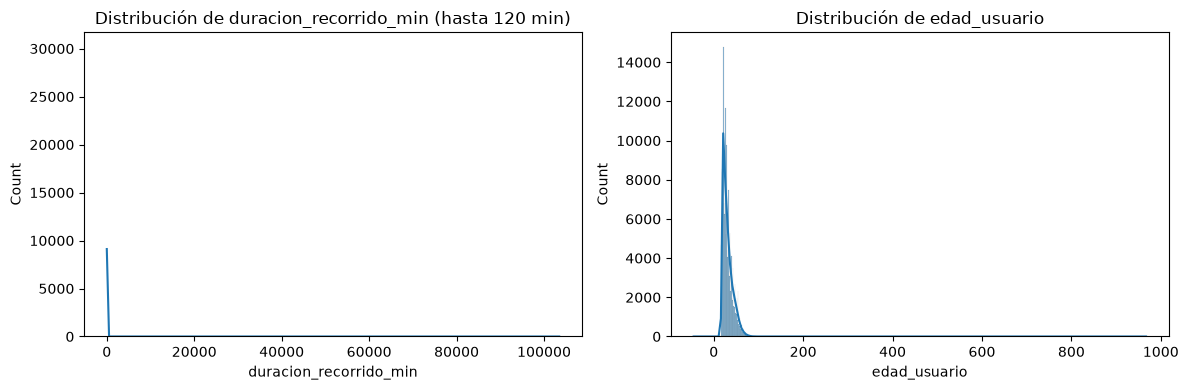

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_recorridos["duracion_recorrido_min"], kde=True, binrange=(0, 120), ax=axes[0])  # hasta 120 min (~99% de los recorridos)
axes[0].set_title("Distribución de duracion_recorrido_min (hasta 120 min)")
sns.histplot(df_usuarios["edad_usuario"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Distribución de edad_usuario")
plt.tight_layout()
plt.show()


#### Cuantitativa discreta: viajes por usuario


In [76]:
plt.figure(figsize=(8, 4))
sns.histplot(viajes_por_usuario, discrete=True)
plt.title("Distribución de la cantidad de viajes por usuario")
plt.xlabel("Cantidad de viajes")
plt.show()


/home/brian/ceia/data-anlysis-ceia/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


KeyboardInterrupt: 

#### Categóricas nominales: frecuencia de cada categoría



--- genero ---
genero
MALE      60.54
FEMALE    30.29
OTHER      9.17
Name: proportion, dtype: float64

--- modelo_bicicleta ---
modelo_bicicleta
FIT       63.12
ICONIC    36.88
Name: proportion, dtype: float64


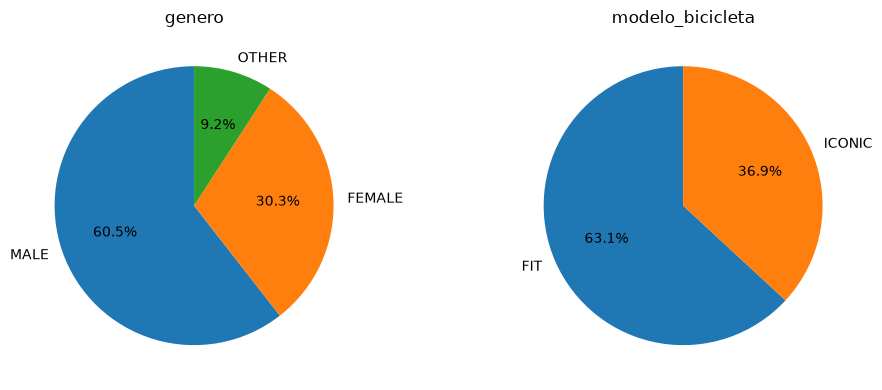

In [ ]:
for col in ["genero", "modelo_bicicleta"]:
    print(f"\n--- {col} ---")
    print((df_recorridos[col].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
genero_counts = df_recorridos["genero"].value_counts()
modelo_counts = df_recorridos["modelo_bicicleta"].value_counts()
axes[0].pie(genero_counts, labels=genero_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("genero")
axes[1].pie(modelo_counts, labels=modelo_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("modelo_bicicleta")
plt.tight_layout()
plt.show()


#### Categórica ordinal: duración agrupada (respeta el orden corto < medio < largo)


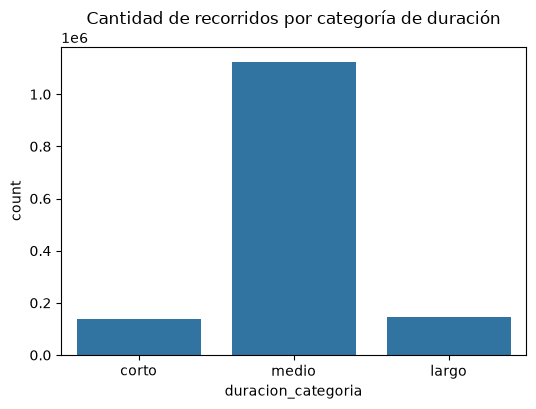

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_recorridos, x="duracion_categoria", order=etiquetas_duracion)
plt.title("Cantidad de recorridos por categoría de duración")
plt.show()


🔍 **A interpretar:** describir la forma de cada distribución (¿simétrica, sesgada hacia
duraciones largas, con varias modas?), si `viajes_por_usuario` muestra el patrón típico de
"pocos usuarios muy frecuentes, muchos usuarios ocasionales", y qué categoría de `genero`,
`modelo_bicicleta` o `duracion_categoria` concentra la mayoría de los recorridos. El punto 4
(errores, outliers y tipo de valores faltantes) se aborda en la próxima tarea.


In [ ]:
### Generar un estudio de cuartiles donde variable sea duración de recorridos 

def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3


In [ ]:
### Generar categorias 

def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")